# 0.1 Task

Swap the LeakyReLUs for **Tanh**. Then run again the experiment and report accuracy on test set.

**Tanh:** Best test accuracy = 0.7055

In [ ]:
import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms


# -----------------------------
# Configuration
# -----------------------------
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
NUM_EPOCHS = 30
NUM_CLASSES = 10
VALIDATION_SPLIT = 0.2

LOG_DIR = "runs/cifar10_tanh_with_val_30epochs"
MODEL_DIR = "saved_models"
MODEL_PATH = os.path.join(MODEL_DIR, "cifar10_tanh_with_val_30epochs.pth")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -----------------------------
# Model
# -----------------------------
class SimpleCNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.Tanh(),
            nn.Linear(256, NUM_CLASSES),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x


# -----------------------------
# Training
# -----------------------------
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    epoch: int,
    writer: SummaryWriter,
) -> tuple[float, float]:
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        global_step = epoch * len(loader) + batch_idx
        writer.add_scalar("Batch/Train_Loss", loss.item(), global_step)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


# -----------------------------
# Evaluation
# -----------------------------
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> tuple[float, float]:
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


# -----------------------------
# Main
# -----------------------------
def main() -> None:
    print(f"Using device: {DEVICE}")

    Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)
    Path(LOG_DIR).mkdir(parents=True, exist_ok=True)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    full_train_dataset = datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=transform,
    )

    test_dataset = datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=transform,
    )

    val_size = int(len(full_train_dataset) * VALIDATION_SPLIT)
    train_size = len(full_train_dataset) - val_size

    train_dataset, val_dataset = random_split(
        full_train_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
    )

    model = SimpleCNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    writer = SummaryWriter(log_dir=LOG_DIR)

    best_val_acc = 0.0

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, epoch, writer
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        writer.add_scalar("Epoch/Train_Loss", train_loss, epoch)
        writer.add_scalar("Epoch/Train_Accuracy", train_acc, epoch)
        writer.add_scalar("Epoch/Validation_Loss", val_loss, epoch)
        writer.add_scalar("Epoch/Validation_Accuracy", val_acc, epoch)

        print(
            f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)

    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    writer.add_scalar("Final/Test_Loss", test_loss, 0)
    writer.add_scalar("Final/Test_Accuracy", test_acc, 0)

    writer.flush()
    writer.close()

    print(f"\nBest validation accuracy: {best_val_acc:.4f}")
    print(f"Final test loss: {test_loss:.4f}")
    print(f"Final test accuracy: {test_acc:.4f}")
    print(f"Model saved to: {MODEL_PATH}")
    print(f"TensorBoard logs saved to: {LOG_DIR}")
    print("\nRun TensorBoard with:")
    print(f"tensorboard --logdir {LOG_DIR}")


if __name__ == "__main__":
    main()

Using device: cpu
Epoch [1/10] | Train Loss: 1.6088 | Train Acc: 0.4276 | Test Loss: 1.4161 | Test Acc: 0.4974
Epoch [2/10] | Train Loss: 1.3005 | Train Acc: 0.5386 | Test Loss: 1.2301 | Test Acc: 0.5656
Epoch [3/10] | Train Loss: 1.1574 | Train Acc: 0.5898 | Test Loss: 1.1214 | Test Acc: 0.6003
Epoch [4/10] | Train Loss: 1.0602 | Train Acc: 0.6258 | Test Loss: 1.0468 | Test Acc: 0.6339
Epoch [5/10] | Train Loss: 0.9832 | Train Acc: 0.6562 | Test Loss: 1.0067 | Test Acc: 0.6426
Epoch [6/10] | Train Loss: 0.9228 | Train Acc: 0.6786 | Test Loss: 0.9523 | Test Acc: 0.6683
Epoch [7/10] | Train Loss: 0.8680 | Train Acc: 0.6957 | Test Loss: 0.9121 | Test Acc: 0.6835
Epoch [8/10] | Train Loss: 0.8206 | Train Acc: 0.7142 | Test Loss: 0.8936 | Test Acc: 0.6884
Epoch [9/10] | Train Loss: 0.7804 | Train Acc: 0.7274 | Test Loss: 0.8907 | Test Acc: 0.6850
Epoch [10/10] | Train Loss: 0.7431 | Train Acc: 0.7419 | Test Loss: 0.8496 | Test Acc: 0.7055

Best test accuracy: 0.7055
Model saved to: saved_m

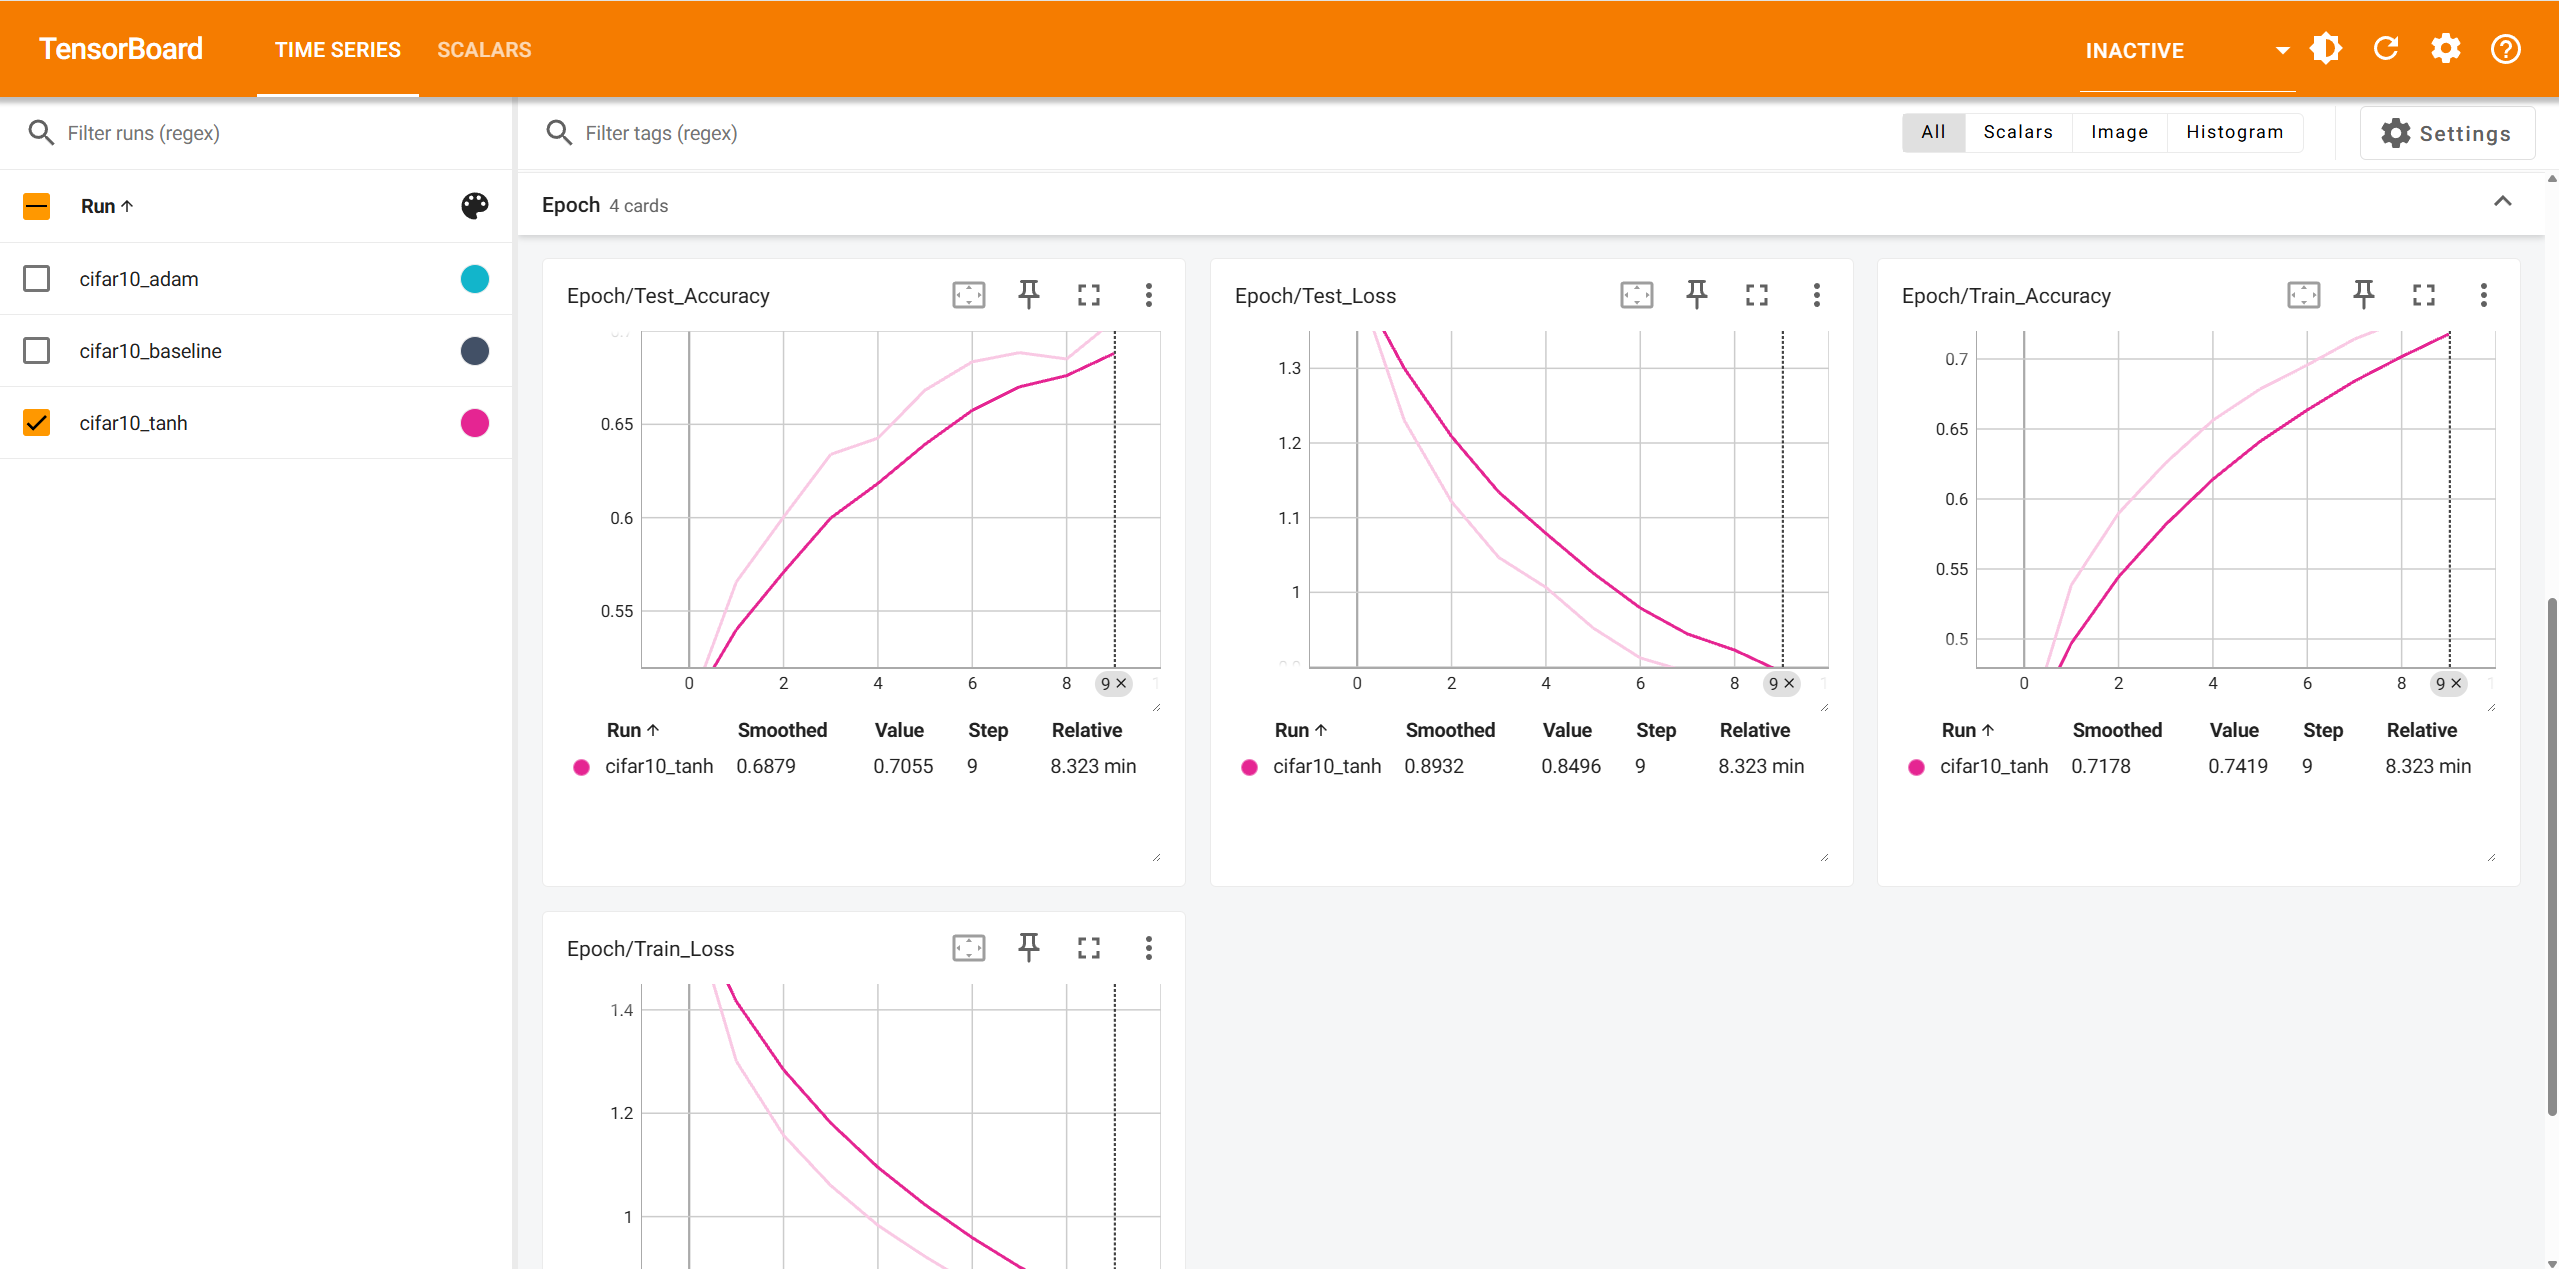